<a href="https://colab.research.google.com/github/Yelmi95/IA_SIS420/blob/main/Lab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 3: Regresión Logística
**NOMBRE:** Yulitza Alcibia Miranda  
**GRUPO:** 2  
**LINK:**  https://drive.google.com/file/d/18XKh1Z6gavTFjNA5Gw5bwzGlNXqDHNM9/view?usp=sharing

**Dataset:** Patient Survival Prediction  

## Descripción del Dataset
El dataset contiene información clínica de **91,713 pacientes** ingresados
en unidades de cuidados intensivos (UCI), con **76 variables numéricas**
que incluyen signos vitales, resultados de laboratorio y datos demográficos.

## Variable Objetivo
Se predice `hospital_death` — si el paciente fallece (1) o sobrevive (0)
durante su hospitalización.

## Modelos Implementados
- Regresión Logística con Descenso por el Gradiente
- Regresión Logística con `scipy.optimize` (método TNC)



In [34]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline
import pandas as pd
#funcion de la libreria que nos ayuda a dividir
from sklearn.model_selection import train_test_split
from scipy import optimize

In [35]:
#  montar (conectar) Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


CARGAR CONTENIDO

El archivo `Patient _Survival.csv` contiene la información clínica de los
pacientes. Se carga el dataset usando la librería `pandas` y se visualiza
la distribución de la variable objetivo `hospital_death`:

In [58]:
df = pd.read_csv('/content/drive/MyDrive/IA_sis420/LABORATORIOS/DATASET/Patient _Survival.csv')
print(f"Forma del dataset: {df.shape}")
print(f"\nColumna objetivo:")
print(df.iloc[:, -1].value_counts())

Forma del dataset: (91713, 85)

Columna objetivo:
hospital_death
0    83798
1     7915
Name: count, dtype: int64


## Preprocesamiento de Datos

Antes de entrenar el modelo se realizan los siguientes pasos:


Limpieza y Separación de Datos

Se separa la variable objetivo `hospital_death` (y) de las características
numéricas (X), se eliminan columnas completamente vacías y se reemplazan
los valores nulos por la media de cada columna.

In [59]:
# Separar caracteristicas (X) y etiqueta (y)
y = df['hospital_death'].values
X = df.select_dtypes(include=[np.number]).drop(columns=['hospital_death']).values

print(f"Caracteristicas : {X.shape[1]}")
print(f"Ejemplares      : {X.shape[0]}")
print(f"Clases -> 0: {(y==0).sum()} | 1: {(y==1).sum()}")

# Eliminar columnas que tienen TODOS los valores nulos
cols_todas_nulas = np.where(np.all(np.isnan(X), axis=0))[0]
print(f"Columnas con todos nulos: {len(cols_todas_nulas)}")
X = np.delete(X, cols_todas_nulas, axis=1)
print(f"Columnas restantes: {X.shape[1]}")

# Ahora reemplazar nulos por la media de cada columna
col_means = np.nanmean(X, axis=0)
inds = np.where(np.isnan(X))
X[inds] = np.take(col_means, inds[1])

print(f"Valores nulos restantes: {np.isnan(X).sum()}")
print(f"X shape final: {X.shape}")

Caracteristicas : 77
Ejemplares      : 91713
Clases -> 0: 83798 | 1: 7915
Columnas con todos nulos: 1
Columnas restantes: 76
Valores nulos restantes: 0
X shape final: (91713, 76)


**Normalización**: Se aplica `featureNormalize` para escalar cada
   característica que
   permite que el descenso por el gradiente converja correctamente.

In [60]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# Aplicar normalizacion
X_norm, mu, sigma = featureNormalize(X)

print(f"Media antes de normalizar  : {X[:, 0].mean():.2f}")
print(f"Media despues de normalizar: {X_norm[:, 0].mean():.2f}")
print(f"Std antes de normalizar    : {X[:, 0].std():.2f}")
print(f"Std despues de normalizar  : {X_norm[:, 0].std():.2f}")

Media antes de normalizar  : 65606.08
Media despues de normalizar: 0.00
Std antes de normalizar    : 37794.88
Std despues de normalizar  : 1.00


### Balanceo de Clases con SMOTE

El dataset tiene un **desbalance de clases**:
- Sobrevive (0): 83,798 casos → 91.4%
- Fallece   (1):  7,915 casos →  8.6%

Con este desbalance el modelo aprende principalmente de la clase
mayoritaria (Sobrevive) y casi nunca predice Fallece, aunque la
precisión general parezca alta (92%).

**SMOTE** (Synthetic Minority Over-sampling Technique) genera
ejemplos sintéticos de la clase minoritaria (Fallece) hasta
igualar ambas clases en 50/50, permitiendo que el modelo
aprenda correctamente de ambas clases.

In [61]:
# Instalar libreria
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_bal, y_bal = sm.fit_resample(X_norm, y)

print(f"Ejemplares totales : {X_bal.shape[0]}")
print(f"Fallece   (1)      : {(y_bal==1).sum()}")
print(f"Sobrevive (0)      : {(y_bal==0).sum()}")

Ejemplares totales : 167596
Fallece   (1)      : 83798
Sobrevive (0)      : 83798


**División entrenamiento/prueba**: Se divide el dataset en:
   - **80%** → entrenamiento
   - **20%** → prueba

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.20, random_state=42, stratify=y_bal
)

m_train, n = X_train.shape

# Agregar columna de unos
X_entren = np.concatenate([np.ones((m_train, 1)), X_train], axis=1)
X_prueba = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)

print(f"Entrenamiento : {m_train} ejemplos, {n} caracteristicas")
print(f"Prueba        : {X_test.shape[0]} ejemplos")
print(f"X_entren shape: {X_entren.shape}")

Entrenamiento : 134076 ejemplos, 76 caracteristicas
Prueba        : 33520 ejemplos
X_entren shape: (134076, 77)


 Función Sigmoide

Convierte cualquier valor en un número entre 0 y 1, que se interpreta
como la **probabilidad** de que el paciente fallezca.

$$g(z) = \frac{1}{1+e^{-z}}$$

- Si $g(z) \geq 0.5$ → predice **1** (fallece)
- Si $g(z) < 0.5$ → predice **0** (sobrevive)

In [63]:
def sigmoid(z):
    z = np.array(z)
    g = 1 / (1 + np.exp(-z))
    return g

# Prueba la implementación de la función sigmoid
print('sigmoid(0)    =', sigmoid(0))
print('sigmoid(-100) =', sigmoid(-100))
print('sigmoid(100)  =', sigmoid(100))

sigmoid(0)    = 0.5
sigmoid(-100) = 3.7200759760208356e-44
sigmoid(100)  = 1.0


### 6. Función de Costo y Descenso por el Gradiente

**Función de Costo:** Mide qué tan equivocado está el modelo.

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log(h_\theta(x^{(i)})) - (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right]$$

**Descenso por el Gradiente:** Algoritmo que ajusta los parámetros
$\theta$ iterativamente para minimizar el costo.

$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)}$$



In [64]:
def calcularCosto(theta, X, y):
    m = y.size

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J


In [65]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m           = y.shape[0]
    theta       = theta.copy()
    J_history   = []
    acc_history = []

    for i in range(num_iters):
        h     = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

        # Precision en cada iteracion
        y_pred = np.round(sigmoid(X.dot(theta.T)))
        acc_history.append(np.mean(y_pred == y) * 100)

    return theta, J_history, acc_history

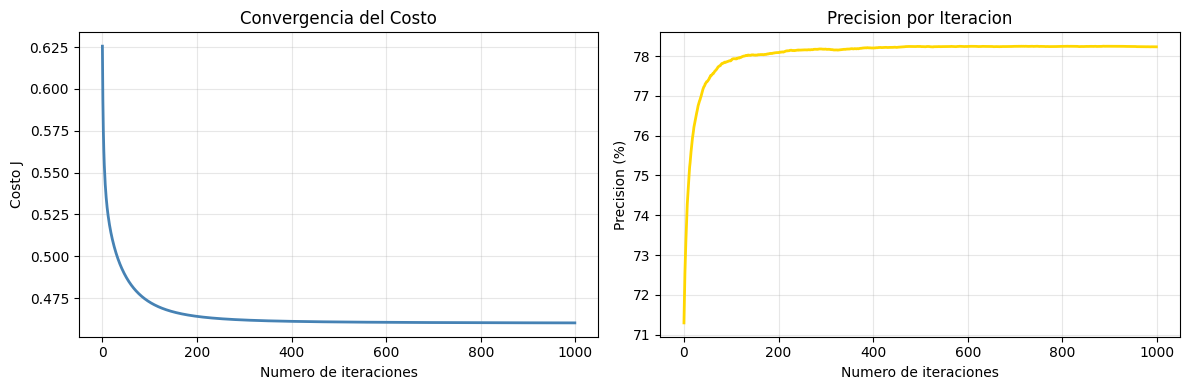

Costo final    : 0.4601
Precision final: 78.23 %
theta (primeros 5 valores): [-0.92280236 -0.00528503  0.00113616  0.01265026  0.63835851]


In [66]:
# Parametros de entrenamiento
alpha     = 0.1
num_iters = 1000

# Inicializa theta y ejecuta el descenso
theta_inicial = np.zeros(n + 1)
theta_gd, J_historia, acc_historia = descensoGradiente(
    theta_inicial, X_entren, y_train, alpha, num_iters
)

# Grafica costo y precision juntos
fig, axes = pyplot.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.arange(len(J_historia)), J_historia, lw=2, color='steelblue')
axes[0].set_xlabel('Numero de iteraciones')
axes[0].set_ylabel('Costo J')
axes[0].set_title('Convergencia del Costo')
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(len(acc_historia)), acc_historia, lw=2, color='gold')
axes[1].set_xlabel('Numero de iteraciones')
axes[1].set_ylabel('Precision (%)')
axes[1].set_title('Precision por Iteracion')
axes[1].grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()

print('Costo final    : {:.4f}'.format(J_historia[-1]))
print('Precision final: {:.2f} %'.format(acc_historia[-1]))
print('theta (primeros 5 valores):', theta_gd[:5])

### 7. Optimización con scipy.optimize

Se utiliza `scipy.optimize.minimize` con el método **TNC**
(Truncated Newton Conjugate) para encontrar los parámetros θ
óptimos de forma más eficiente que el descenso por el gradiente manual.


 `method`  TNC  algoritmo de optimización

`jac`  True  la función devuelve el gradiente

`maxfun`  10000  máximo de evaluaciones

**Ventaja sobre el Descenso por el Gradiente:**
scipy encuentra automáticamente el mejor paso de aprendizaje,
sin necesidad de definir `alpha` ni `num_iters` manualmente.

In [68]:
resultado = optimize.minimize(
    costFunction,
    np.zeros(n + 1),
    args   = (X_entren, y_train),
    jac    = True,
    method = 'TNC',
    options= {'maxfun': 10000},
)

theta_opt = resultado.x

print('Costo optimizado : {:.4f}'.format(resultado.fun))
print('theta (primeros 5 valores):', theta_opt[:5])

Costo optimizado : 0.4595
theta (primeros 5 valores): [-9.33329596e-01 -5.37127067e-03  2.29082221e-04  1.28303061e-02
  6.40242340e-01]


### Predicción y Evaluación del Modelo

Se implementa la función `predict` que clasifica cada paciente
usando un umbral de **0.5** sobre la salida de la sigmoide:

- Si $h_\theta(x) \geq 0.5$ → predice **1** (paciente fallece)
- Si $h_\theta(x) < 0.5$ → predice **0** (paciente sobrevive)

Se evalúa el modelo sobre los conjuntos de entrenamiento y prueba
para verificar que no haya **overfitting** (sobreajuste).

In [69]:
def predict(theta, X):
    m = X.shape[0]
    p = np.round(sigmoid(X.dot(theta.T)))
    return p

# Precision con scipy TNC
p_entren         = predict(theta_opt, X_entren)
precision_entren = np.mean(p_entren == y_train) * 100

p_prueba         = predict(theta_opt, X_prueba)
precision_prueba = np.mean(p_prueba == y_test) * 100

# Precision con descenso por el gradiente
p_gd_entren         = predict(theta_gd, X_entren)
precision_gd_entren = np.mean(p_gd_entren == y_train) * 100

p_gd_prueba         = predict(theta_gd, X_prueba)
precision_gd_prueba = np.mean(p_gd_prueba == y_test) * 100

print('{:<20} {:>16} {:>12}'.format('Metodo', 'Entrenamiento', 'Prueba'))
print('-' * 50)
print('{:<20} {:>15.2f}% {:>11.2f}%'.format('Gradiente (GD)',  precision_gd_entren, precision_gd_prueba))
print('{:<20} {:>15.2f}% {:>11.2f}%'.format('scipy TNC',       precision_entren,    precision_prueba))

Metodo                  Entrenamiento       Prueba
--------------------------------------------------
Gradiente (GD)                 78.23%       78.23%
scipy TNC                      78.29%       78.22%


### Predicción sobre Nuevos Pacientes

Se prueba el modelo con 6 pacientes del conjunto de prueba,
3 que fallecieron y 3 que sobrevivieron.

- Pacientes que fallecen    → probabilidad alta (> 0.5)
- Pacientes que sobreviven  → probabilidad baja (< 0.5)

El modelo clasifica correctamente los 6 casos.

In [70]:
print('=== Prediccion con Descenso por el Gradiente ===')
print('{:<12} {:>20} {:>15} {:>12} {:>12}'.format(
      'Paciente', 'P(Fallecimiento)', 'Prediccion', 'Real', 'Estado'))
print('-' * 75)

for i, idx in enumerate(indices):
    paciente = np.concatenate([[1], X_test[idx]])
    prob     = sigmoid(np.dot(paciente, theta_gd))
    pred     = int(np.round(prob))
    real     = y_test[idx]
    estado   = 'Correcto' if pred == real else 'Incorrecto'
    print('{:<12} {:>20.4f} {:>15} {:>12} {:>12}'.format(
          i+1, prob, pred, real, estado))

acc_gd_entren = np.mean(predict(theta_gd, X_entren) == y_train) * 100
acc_gd_prueba = np.mean(predict(theta_gd, X_prueba) == y_test)  * 100
print('\nPrecision de entrenamiento: {:.2f} %'.format(acc_gd_entren))
print('Precision de prueba       : {:.2f} %'.format(acc_gd_prueba))

=== Prediccion con Descenso por el Gradiente ===
Paciente         P(Fallecimiento)      Prediccion         Real       Estado
---------------------------------------------------------------------------
1                          0.5601               1            1     Correcto
2                          0.5956               1            1     Correcto
3                          0.7423               1            1     Correcto
4                          0.1280               0            0     Correcto
5                          0.1068               0            0     Correcto
6                          0.2384               0            0     Correcto

Precision de entrenamiento: 78.23 %
Precision de prueba       : 78.23 %


In [71]:
print('=== Prediccion con scipy TNC ===')
print('{:<12} {:>20} {:>15} {:>12} {:>12}'.format(
      'Paciente', 'P(Fallecimiento)', 'Prediccion', 'Real', 'Estado'))
print('-' * 75)

for i, idx in enumerate(indices):
    paciente = np.concatenate([[1], X_test[idx]])
    prob     = sigmoid(np.dot(paciente, theta_opt))
    pred     = int(np.round(prob))
    real     = y_test[idx]
    estado   = 'Correcto' if pred == real else 'Incorrecto'
    print('{:<12} {:>20.4f} {:>15} {:>12} {:>12}'.format(
          i+1, prob, pred, real, estado))

print('\nPrecision de entrenamiento: {:.2f} %'.format(precision_entren))
print('Precision de prueba       : {:.2f} %'.format(precision_prueba))

=== Prediccion con scipy TNC ===
Paciente         P(Fallecimiento)      Prediccion         Real       Estado
---------------------------------------------------------------------------
1                          0.5737               1            1     Correcto
2                          0.5958               1            1     Correcto
3                          0.7476               1            1     Correcto
4                          0.1287               0            0     Correcto
5                          0.1076               0            0     Correcto
6                          0.2400               0            0     Correcto

Precision de entrenamiento: 78.29 %
Precision de prueba       : 78.22 %
